# MobileNetV2 for Diabetic Foot Ulcer (DFU) Image Classification
This notebook trains a **MobileNetV2** model using transfer learning on DFU images with **5-Fold Cross-Validation**.  
Designed to run on **Kaggle GPU** environment.  
Uses the **same preprocessing & training configuration** as the DenseNet121 DFU notebook:
- **Optimizer**: Adam (lr = 1e-3)
- **Scheduler**: ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)
- **EarlyStopping**: patience = 7
- **Class weights**: balanced (sklearn)
- **Augmentation**: H-flip, V-flip, Rotation +/-20, Zoom +/-20%, Brightness +/-10%, Contrast +/-10%

In [1]:
# Kaggle Setup - Clone repo & install dependencies
import os

REPO_URL    = 'https://github.com/csstudentkaum/KHOTAA.git'
BRANCH      = 'new-start'
REPO_DIR    = '/kaggle/working/KHOTAA'
WORKING_DIR = os.path.join(REPO_DIR, 'models', 'classification')

if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
    print(f'Cloned {BRANCH} branch')
else:
    print(f'Repo already exists at {REPO_DIR}')

os.chdir(WORKING_DIR)
print(f'Working directory: {os.getcwd()}')

!pip install roboflow -q
print('Kaggle setup complete')

Cloning into '/kaggle/working/KHOTAA'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 583 (delta 32), reused 36 (delta 25), pack-reused 535 (from 1)
Receiving objects: 100% (583/583), 20.83 MiB | 34.91 MiB/s, done.
Resolving deltas: 100% (277/277), done.
Cloned new-start branch
Working directory: /kaggle/working/KHOTAA/models/classification
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.3 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

## 1. Imports & Configuration

In [2]:
import sys, os, random, warnings, json
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime
import copy

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sys.path.append('../')
sys.path.append('./')

import importlib
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import training_engine
importlib.reload(training_engine)
from utils.training_engine import (
    TrainingEngine, create_optimizer, create_scheduler,
    compute_balanced_class_weights
)
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_curve, plot_training_history
)

IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 1e-3
FINE_TUNE_LR  = 1e-5
N_FOLDS       = 5

from roboflow import Roboflow
rf = Roboflow(api_key="aOyWN2odFMV7P4HudwVJ")
project = rf.workspace("dfu-o28ut").project("dfu-kew1f-gzodp")
version = project.version(1)
dataset = version.download("folder")
DATASET_PATH = dataset.location + "/"

MODEL_NAME  = 'MobileNetV2'
RESULTS_DIR = 'results'

print('Imports complete (modules reloaded)')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'Image size      : {IMAGE_SIZE}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Dataset path    : {DATASET_PATH}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DFU-1 in folder:: 100%|██████████| 4462/4462 [00:00<00:00, 12248.67it/s]

Imports complete (modules reloaded)
PyTorch version : 2.9.0+cu126
CUDA available  : True
Image size      : (224, 224)
Batch size      : 32
Dataset path    : /kaggle/working/KHOTAA/models/classification/DFU-1/


## 2. Load & Explore Dataset

In [3]:
print('Dataset root contents:')
for entry in sorted(os.listdir(DATASET_PATH)):
    full = os.path.join(DATASET_PATH, entry)
    kind = 'DIR' if os.path.isdir(full) else 'FILE'
    print(f'  [{kind}] {entry}')

loader = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f'\nClasses: {classes}')
print(f'Number of classes: {num_classes}')

loader.print_structure()

preprocessor = DFUPreprocessing()
train_transform    = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f'\nTotal training samples (train+valid): {len(X_all)}')
print('Dataset loaded and ready for 5-fold cross-validation')

Dataset root contents:
  [FILE] README.roboflow.txt
  [DIR] test
  [DIR] train
  [DIR] valid
[DatasetLoader] Root: /kaggle/working/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']

Classes: ['Both', 'Infection', 'Ischaemia', 'None']
Number of classes: 4

Dataset root: /kaggle/working/KHOTAA/models/classification/DFU-1
  [FILE] README.roboflow.txt
  [DIR] test
  [DIR] train
  [DIR] valid

[DatasetLoader] Split 'train': 3112 images
  Split 'train' (3112 images):
    Both: 323  (10.4%)
    Infection: 1327  (42.6%)
    Ischaemia: 111  (3.6%)
    None: 1351  (43.4%)
[DatasetLoader] Split 'valid': 889 images
  Split 'valid' (889 images):
    Both: 93  (10.5%)
    Infection: 381  (42.9%)
    Ischaemia: 41  (4.6%)
    None: 374  (42.1%)
[DatasetLoader] Split 'test': 445 images
  Split 'test' (445 images):
    Both: 45  (10.1%)
    Infection: 193  (43.4%)
    Ischaemia: 15  (3.4%)
    No

[DatasetLoader] Split 'train': 3112 images


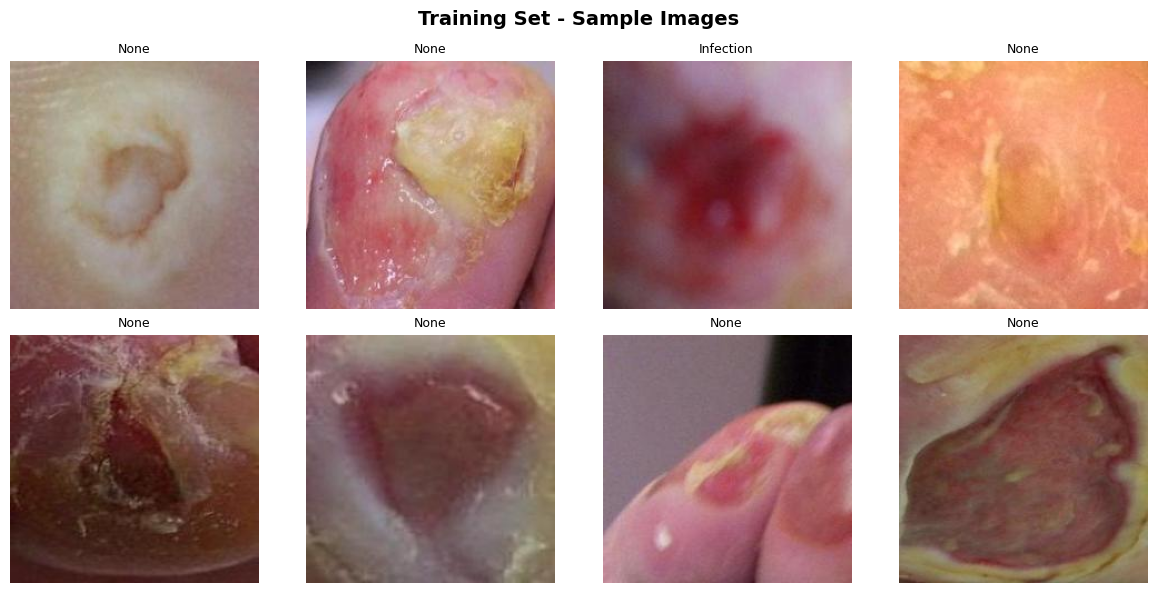

In [4]:
loader.show_samples('train', n_cols=4, n_rows=2, title='Training Set - Sample Images')

[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
[DatasetLoader] Split 'test': 445 images


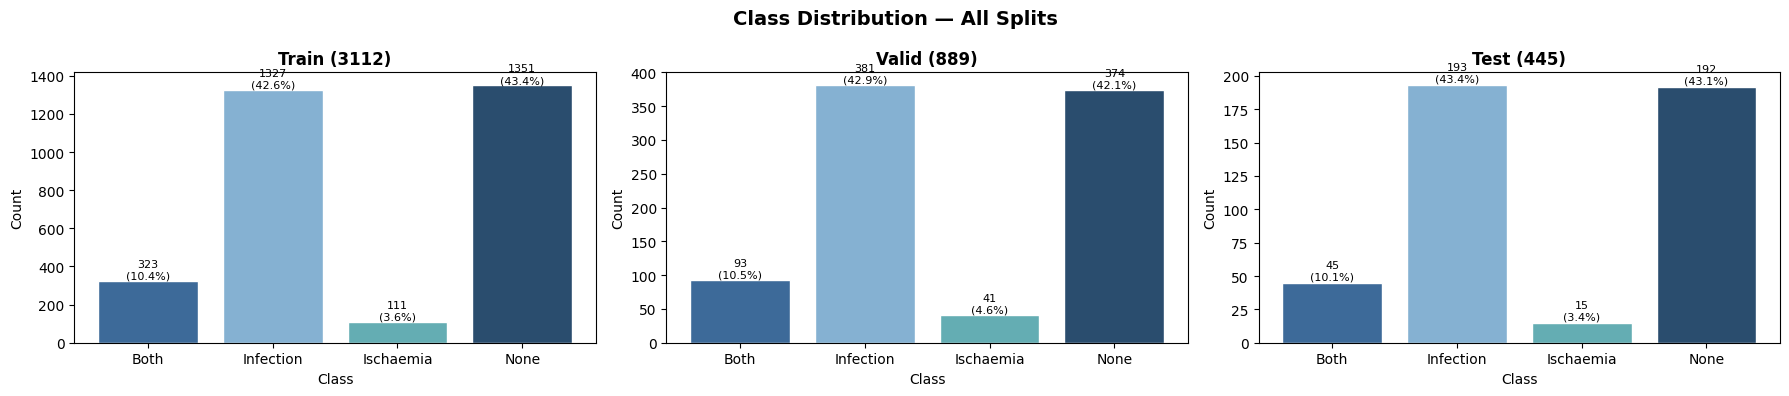

Total training+val samples: 4001
Class counts: {'Both': 416, 'Infection': 1708, 'Ischaemia': 152, 'None': 1725}


In [5]:
import matplotlib.pyplot as plt

PALETTE = ["#3D6A99", "#85B1D2", "#64ADB3", "#2A4D6E"]

original_show = plt.show

def custom_show():
    fig = plt.gcf()
    for ax in fig.axes:
        for i, bar in enumerate(ax.patches):
            bar.set_facecolor(PALETTE[i % len(PALETTE)])
            bar.set_edgecolor('white')
    original_show()

plt.show = custom_show
loader.plot_all_splits_distribution()
plt.show = original_show

print(f'Total training+val samples: {len(y_all)}')
print(f'Class counts: { {classes[i]: int(np.sum(y_all == i)) for i in range(num_classes)} }')

## 3. Data Preprocessing & Augmentation Visualization

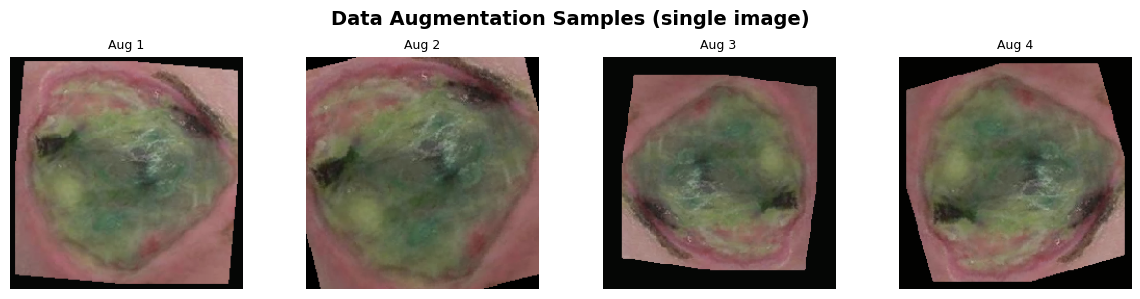

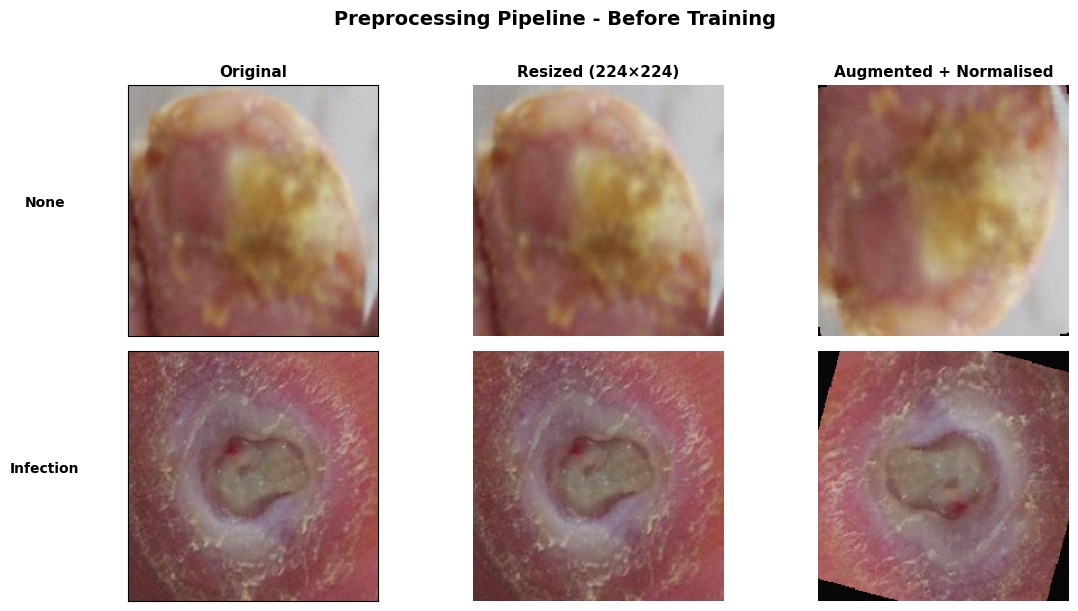

Note: PyTorch applies augmentation on-the-fly during training,
so class counts remain the same. Augmentation adds visual variety, not extra samples.


In [6]:
sample_path = X_train[0]
preprocessor.show_augmentation_samples(
    sample_path, n_samples=4,
    title='Data Augmentation Samples (single image)'
)

preprocessor.show_preprocessing_samples(
    X_train, y_train, classes,
    n_samples=2,
    title='Preprocessing Pipeline - Before Training'
)

print('Note: PyTorch applies augmentation on-the-fly during training,')
print('so class counts remain the same. Augmentation adds visual variety, not extra samples.')

## 4. Build Model (Transfer Learning)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def create_mobilenet_model(num_classes=4, pretrained=True):
    """
    Create MobileNetV2 model for DFU classification.
    Architecture:
        MobileNetV2 backbone -> AdaptiveAvgPool2d -> Flatten
        -> Dropout(0.2) -> Linear(1280 -> num_classes)
    """
    if pretrained:
        model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    else:
        model = models.mobilenet_v2(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

test_model = create_mobilenet_model(num_classes=num_classes)
total_params     = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print(f'\nMobileNetV2 model created')
print(f'Input size       : 224x224')
print(f'Output classes   : {num_classes}')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')
print(f'Final classifier : {test_model.classifier[1]}')
del test_model

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 116MB/s] 


MobileNetV2 model created
Input size       : 224x224
Output classes   : 4
Total params     : 2,228,996
Trainable params : 2,228,996
Final classifier : Linear(in_features=1280, out_features=4, bias=True)


## 5. Class Weights

Compute balanced class weights to handle class imbalance.

In [8]:
class_weights_tensor = compute_balanced_class_weights(y_all, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f'\nCrossEntropyLoss with balanced class weights')
print(f'  Weights: {class_weights_tensor.cpu().numpy()}')
print(f'  Classes: {classes}')

[ClassWeights] Balanced class weights: {0: 2.4044471153846154, 1: 0.5856264637002342, 2: 6.5805921052631575, 3: 0.5798550724637681}

CrossEntropyLoss with balanced class weights
  Weights: [2.404447  0.5856265 6.580592  0.5798551]
  Classes: ['Both', 'Infection', 'Ischaemia', 'None']


## 6. Training (5-Fold Cross-Validation)

Training configuration (aligned with DenseNet121 notebook):
- **Optimizer**: Adam (lr = 1e-3)
- **Scheduler**: ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)
- **EarlyStopping**: patience = 7, monitors val_loss, restores best weights
- **Loss**: CrossEntropyLoss with balanced class weights
- **Epochs**: 30 max per fold

In [9]:
fold_results = []
best_model_state = None
best_overall_acc = 0.0
fold_model_states = {}

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
    print(f"\n{'='*60}\nFOLD {fold}/{N_FOLDS}\n{'='*60}")
    
    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold   = X_all[val_idx]
    y_val_fold   = y_all[val_idx]
    
    train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_dataset   = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    model = create_mobilenet_model(num_classes=num_classes, pretrained=True)
    model = model.to(device)
    
    optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                                 gamma=0.3, patience=3, min_lr=1e-7)
    
    engine = TrainingEngine(model=model, device=device)
    
    fold_best_state = None
    fold_best_acc = 0.0
    
    from utils.training_engine import EarlyStopping
    early_stopper = EarlyStopping(patience=7, verbose=True)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'stopped_epoch': EPOCHS
    }
    
    for epoch in range(EPOCHS):
        print(f"\n{'='*60}")
        print(f'Epoch {epoch+1}/{EPOCHS}')
        print(f"{'='*60}")
        
        train_loss, train_acc = engine.train_epoch(train_loader, criterion, optimizer)
        val_loss, val_acc, _, _, _ = engine.evaluate(val_loader, criterion, measure_inference_time=False)
        
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Learning Rate: {current_lr:.6f}')
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'\nEpoch {epoch+1} Results:')
        print(f'   Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
        print(f'   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%')
        
        if val_acc > fold_best_acc:
            fold_best_acc = val_acc
            fold_best_state = copy.deepcopy(model.state_dict())
            print(f'   New best model! Val Acc: {val_acc*100:.2f}%')
        
        if early_stopper(val_loss, epoch+1):
            history['stopped_epoch'] = epoch + 1
            print(f"\n{'='*60}")
            print(f'Training stopped early at epoch {epoch+1}/{EPOCHS}')
            print(f'Best Validation Accuracy: {fold_best_acc*100:.2f}%')
            print(f"{'='*60}\n")
            break
    else:
        history['stopped_epoch'] = EPOCHS
        print(f"\n{'='*60}")
        print(f'Training Complete! All {EPOCHS} epochs')
        print(f'Best Validation Accuracy: {fold_best_acc*100:.2f}%')
        print(f"{'='*60}\n")
    
    fold_model_states[fold] = fold_best_state
    
    if fold_best_acc > best_overall_acc:
        best_overall_acc = fold_best_acc
        best_model_state = copy.deepcopy(fold_best_state)
    
    best_val_acc = fold_best_acc
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'stopped_epoch': history['stopped_epoch'],
        'history': history
    })
    print(f"Fold {fold} - Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")

avg_acc    = np.mean([r['best_val_acc'] for r in fold_results])
std_acc    = np.std([r['best_val_acc'] for r in fold_results])
avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n{'='*60}")
print('5-FOLD CROSS-VALIDATION RESULTS')
print(f"{'='*60}")
print(f'Mean Accuracy: {avg_acc*100:.2f}% +/- {std_acc*100:.2f}%')
print(f'Average Epochs: {avg_epochs:.1f}')
print(f'\nIndividual Fold Results:')
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
print(f"{'='*60}")


FOLD 1/5
Created Adam optimizer: lr=0.001, weight_decay=0.0001
Created ReduceLROnPlateau scheduler: mode=min, patience=3, factor=0.3, min_lr=1e-07
Training on: cuda

Epoch 1/30


Evaluating: 100%|██████████| 26/26 [00:01<00:00, 14.26it/s, loss=1.6418, acc=63.30%]


Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.0766 | Train Acc: 53.75%
   Val Loss:   0.8113 | Val Acc:   63.30%
   New best model! Val Acc: 63.30%

Epoch 2/30


Evaluating: 100%|██████████| 26/26 [00:01<00:00, 15.32it/s, loss=1.1718, acc=64.67%]


Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 0.8891 | Train Acc: 62.53%
   Val Loss:   0.7031 | Val Acc:   64.67%
   New best model! Val Acc: 64.67%

Epoch 3/30


...

Learning Rate: 0.000300

Epoch 18 Results:
   Train Loss: 0.5914 | Train Acc: 70.98%
   Val Loss:   0.6328 | Val Acc:   72.12%
   New best model! Val Acc: 72.12%

Epoch 19/30


Evaluating: 100%|██████████| 25/25 [00:01<00:00, 14.81it/s, loss=0.4509, acc=70.75%]


Learning Rate: 0.000300

Epoch 19 Results:
   Train Loss: 0.5388 | Train Acc: 72.76%
   Val Loss:   0.6735 | Val Acc:   70.75%

Epoch 20/30


Evaluating: 100%|██████████| 25/25 [00:01<00:00, 14.74it/s, loss=0.4184, acc=70.75%]

Learning Rate: 0.000300

Epoch 20 Results:
   Train Loss: 0.5541 | Train Acc: 71.92%
   Val Loss:   0.6380 | Val Acc:   70.75%
SUCCESS: Early stopping triggered at epoch 20
Best validation loss was 0.6221 at epoch 13

Training stopped early at epoch 20/30
Best Validation Accuracy: 72.12%

Fold 5 - Best Acc: 72.12% (stopped at epoch 20)

5-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy: 75.38% +/- 2.14%
Average Epochs: 24.4

Individual Fold Results:
  Fold 1: 78.65% (epoch 30)
  Fold 2: 75.62% (epoch 30)
  Fold 3: 76.12% (epoch 23)
  Fold 4: 74.38% (epoch 19)
  Fold 5: 72.12% (epoch 20)


## 7. Training Curves & Evaluation Plots

Results directory: /kaggle/working/KHOTAA/models/classification/results/mobilenetv2
Best fold: 1 (78.65%)
Loaded best model from MEMORY


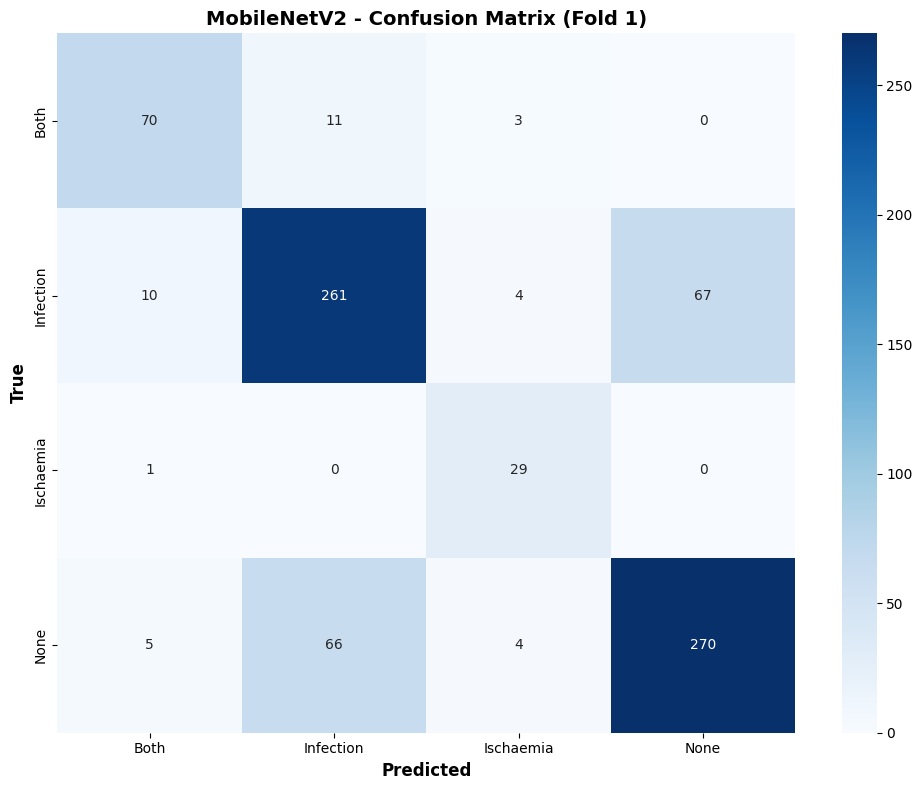


Generating aggregated confusion matrix across all folds...
  Fold 1 processed
  Fold 2 processed
  Fold 3 processed
  Fold 4 processed
  Fold 5 processed


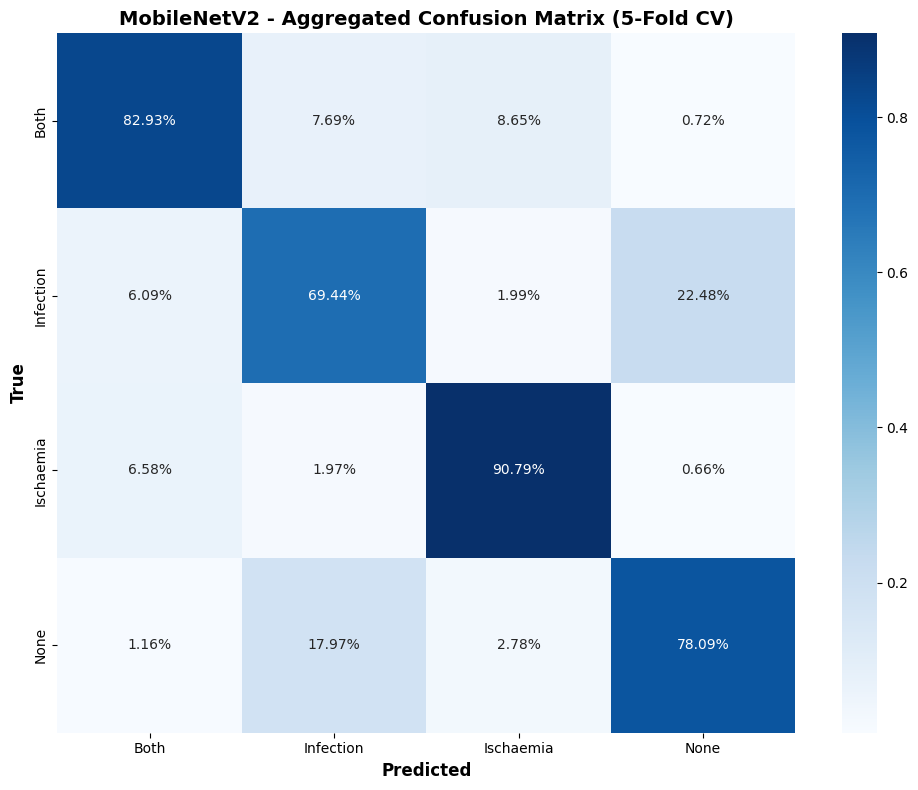

Aggregated CM saved (4001 total predictions)


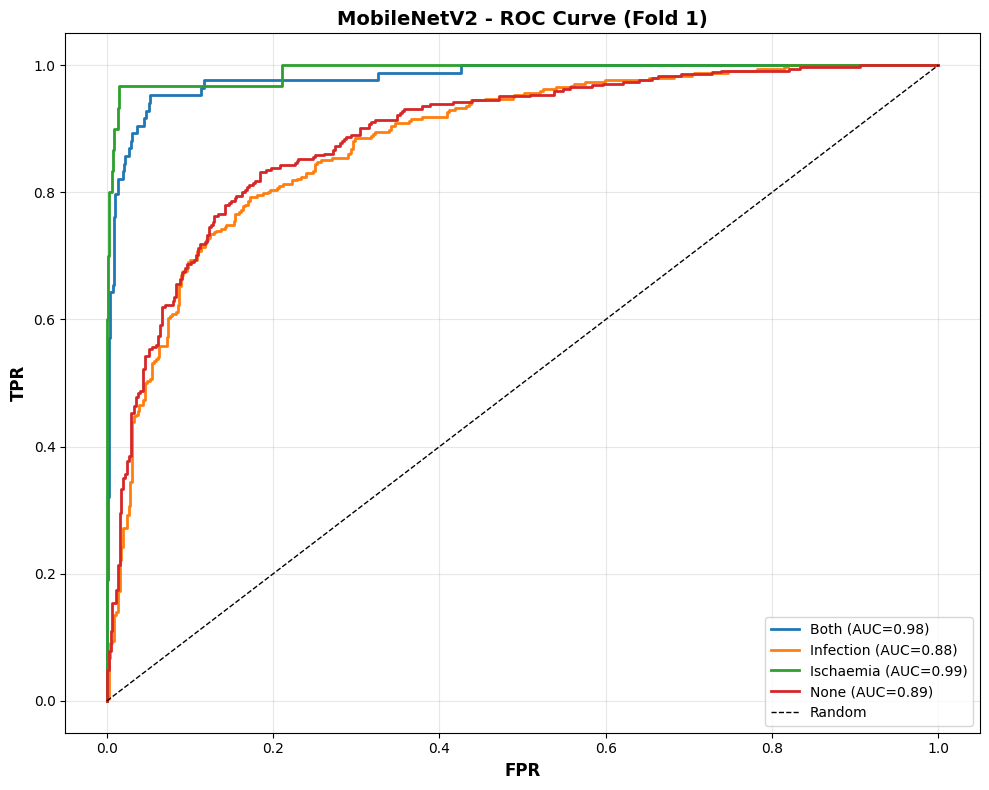

In [ ]:
DPI = 300
PLOT_CONFIG = {
    'cm':      {'size': (10, 8), 'cmap': 'Blues'},
    'roc':     {'size': (10, 8), 'lw': 2},
    'history': {'size': (18, 10)},
}
FONT = {'title': 14, 'label': 12, 'legend': 10, 'tick': 10}

model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
os.makedirs(model_results_dir, exist_ok=True)
print(f'Results directory: {os.path.abspath(model_results_dir)}')

# Load best model from memory
best_fold_idx = int(np.argmax([r['best_val_acc'] for r in fold_results]))
best_fold_num = fold_results[best_fold_idx]['fold']

model = create_mobilenet_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(best_model_state)
model = model.to(device).eval()
print(f'Best fold: {best_fold_num} ({fold_results[best_fold_idx]["best_val_acc"]*100:.2f}%)')
print('Loaded best model from MEMORY')

# Get predictions (best fold)
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

# 1. Confusion Matrix (best fold)
cm = confusion_matrix(true_labels, predictions)
fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm, annot=True, fmt='d', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - Confusion Matrix (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# 2. Aggregated Confusion Matrix (all 5 folds from memory)
print('\nGenerating aggregated confusion matrix across all folds...')
cm_aggregated = np.zeros((num_classes, num_classes), dtype=int)

for fold_idx, (train_idx_f, val_idx_f) in enumerate(fold_splits, 1):
    val_dataset_fold = DFUDataset(X_all[val_idx_f], y_all[val_idx_f], transform=val_test_transform)
    val_loader_fold  = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    if fold_idx in fold_model_states:
        model_f = create_mobilenet_model(num_classes=num_classes, pretrained=False)
        model_f.load_state_dict(fold_model_states[fold_idx])
        model_f = model_f.to(device).eval()
        
        fold_preds, fold_labels = [], []
        with torch.no_grad():
            for inp, lbl in val_loader_fold:
                out = model_f(inp.to(device))
                fold_preds.append(torch.max(out, 1)[1].cpu().numpy())
                fold_labels.append(lbl.numpy())
        
        fp = np.concatenate(fold_preds)
        fl = np.concatenate(fold_labels)
        cm_aggregated += confusion_matrix(fl, fp, labels=range(num_classes))
        print(f'  Fold {fold_idx} processed')
        del model_f
    else:
        print(f'  Fold {fold_idx} model state not in memory, skipping')

if cm_aggregated.sum() > 0:
    cm_aggregated_norm = cm_aggregated.astype('float') / cm_aggregated.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
    sns.heatmap(cm_aggregated_norm, annot=True, fmt='.2%', cmap=PLOT_CONFIG['cm']['cmap'],
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
    ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
    ax.set_title(f'{MODEL_NAME} - Aggregated Confusion Matrix (5-Fold CV)',
                 fontsize=FONT['title'], fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_aggregated.png',
                dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'Aggregated CM saved ({cm_aggregated.sum()} total predictions)')
else:
    print('No fold model states found in memory - skipping aggregated confusion matrix')

# 3. ROC Curve (best fold)
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=PLOT_CONFIG['roc']['size'])
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, linewidth=PLOT_CONFIG['roc']['lw'],
            label=f'{classes[i]} (AUC={auc(fpr, tpr):.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('TPR', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - ROC Curve (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
ax.legend(loc='lower right', fontsize=FONT['legend'])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# 4. All Folds - Training History (Loss)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Loss)',
             fontsize=FONT['title']+2, fontweight='bold')
for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_loss']) + 1)
    ax.plot(ep, h['train_loss'], 'b-', label='Train', lw=2)
    ax.plot(ep, h['val_loss'],   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_loss'].index(min(h['val_loss'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Loss', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_loss.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# 5. All Folds - Training History (Accuracy)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Accuracy)',
             fontsize=FONT['title']+2, fontweight='bold')
for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_acc']) + 1)
    train_pct = [a * 100 for a in h['train_acc']]
    val_pct   = [a * 100 for a in h['val_acc']]
    ax.plot(ep, train_pct, 'b-', label='Train', lw=2)
    ax.plot(ep, val_pct,   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_acc'].index(max(h['val_acc'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Accuracy (%)', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])
axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_accuracy.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# 6. Best Fold - Detailed Training Curves
best_history = fold_results[best_fold_idx]['history']
epochs_range = range(1, len(best_history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{MODEL_NAME} - Best Fold {best_fold_num}',
             fontsize=FONT['title']+4, fontweight='bold')
ax1.plot(epochs_range, best_history['train_loss'], 'b-', label='Train', lw=2.5)
ax1.plot(epochs_range, best_history['val_loss'],   'r-', label='Val',   lw=2.5)
ax1.axvline(x=best_history['val_loss'].index(min(best_history['val_loss'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax1.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_title(f'Fold {best_fold_num}: Loss', fontsize=FONT['title'], fontweight='bold')
ax1.legend(fontsize=FONT['legend']+2)
ax1.grid(alpha=0.3)
ax2.plot(epochs_range, [a*100 for a in best_history['train_acc']], 'b-', label='Train', lw=2.5)
ax2.plot(epochs_range, [a*100 for a in best_history['val_acc']],   'r-', label='Val',   lw=2.5)
ax2.axvline(x=best_history['val_acc'].index(max(best_history['val_acc'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax2.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_title(f'Fold {best_fold_num}: Accuracy', fontsize=FONT['title'], fontweight='bold')
ax2.legend(fontsize=FONT['legend']+2)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 105])
plt.tight_layout()
plt.show()

# Save CV Results JSON
results = {
    'model_name': MODEL_NAME,
    'cv_results': {
        'val_accuracy': {'mean': float(avg_acc), 'std': float(std_acc)},
        'avg_epochs': float(avg_epochs),
        'fold_results': [
            {'fold': r['fold'], 'best_val_acc': float(r['best_val_acc']),
             'stopped_epoch': int(r['stopped_epoch'])}
            for r in fold_results
        ]
    },
    'best_fold': {
        'fold_number': best_fold_num,
        'best_val_acc': float(fold_results[best_fold_idx]['best_val_acc']),
        'loaded_from': 'memory'
    }
}
with open(f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f'{MODEL_NAME} CROSS-VALIDATION SUMMARY')
print(f"{'='*60}")
print(f'Mean Accuracy: {avg_acc*100:.2f}% +/- {std_acc*100:.2f}%')
print(f'Best Fold: {best_fold_num} ({fold_results[best_fold_idx]["best_val_acc"]*100:.2f}%)')
print(f'Model loaded from: MEMORY')
print(f'Average Epochs: {avg_epochs:.1f}')
print(f'Results saved -> {model_results_dir}/{MODEL_NAME.lower()}_cv_results.json')
print(f"{'='*60}")

## 8. Generate Comprehensive Metrics JSON

This cell generates a standalone comprehensive metrics JSON file from the in-memory model state.  
It includes **ROC curve data (FPR/TPR per class)** for cross-model ROC comparison.

In [12]:
import sys, os, json, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import MobileNet_V2_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, auc,
                             matthews_corrcoef, cohen_kappa_score, log_loss)
from sklearn.preprocessing import label_binarize
from datetime import datetime
from PIL import Image

sys.path.append('../'); sys.path.append('./')
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing

print('='*80)
print('GENERATING COMPREHENSIVE METRICS')
print('='*80)

MODEL_NAME     = 'MobileNetV2'
BATCH_SIZE     = 32
RESULTS_DIR    = 'results'
N_FOLDS        = 5
SEED           = 42

print('\n[1/4] Loading dataset...')
loader      = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes     = loader.get_classes()
num_classes = loader.get_num_classes()

preprocessor       = DFUPreprocessing()
val_test_transform = preprocessor.get_valid_test_transforms()

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

kfold  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Loaded {len(X_all)} training samples')
print(f'Classes: {classes}')

def create_mobilenet_model(num_classes=4, pretrained=False):
    if pretrained:
        model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    else:
        model = models.mobilenet_v2(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

print('\n[2/4] Loading saved results...')
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
results_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json'

if not os.path.exists(results_json_path):
    raise FileNotFoundError(f'Results file not found: {results_json_path}')

with open(results_json_path, 'r') as f:
    saved_results = json.load(f)

fold_results_sec9 = []
for fd in saved_results['cv_results']['fold_results']:
    fold_results_sec9.append({
        'fold':         fd['fold'],
        'best_val_acc': fd['best_val_acc'],
        'final_val_acc': fd.get('final_val_acc', fd['best_val_acc']),
        'stopped_epoch': fd['stopped_epoch']
    })

avg_acc    = saved_results['cv_results']['val_accuracy']['mean']
std_acc    = saved_results['cv_results']['val_accuracy']['std']
avg_epochs = saved_results['cv_results']['avg_epochs']

print(f'Loaded CV results: {avg_acc*100:.2f}% +/- {std_acc*100:.2f}%')

print('\n[3/4] Loading best model & evaluating on validation set...')

best_fold_idx_s9 = int(np.argmax([r['best_val_acc'] for r in fold_results_sec9]))
best_fold_num_s9 = fold_results_sec9[best_fold_idx_s9]['fold']

model = create_mobilenet_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(best_model_state)
model = model.to(device).eval()
print(f'Loaded best model from MEMORY (fold {best_fold_num_s9})')

fold_splits        = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx_s9]
val_dataset        = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader         = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs   = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

print(f'Evaluated {len(true_labels)} validation samples')

print('\n[4/4] Calculating comprehensive metrics...')

y_true_bin = label_binarize(true_labels, classes=range(num_classes))

def compute_all_metrics(y_true, y_pred, y_proba, y_true_bin, class_names, n_classes):
    pcm = {}
    roc_data = {}
    for i, cname in enumerate(class_names):
        mask  = (y_true == i)
        cpred = (y_pred == i)
        tp = int(np.sum(cpred & mask))
        fp = int(np.sum(cpred & ~mask))
        fn = int(np.sum(~cpred & mask))
        tn = int(np.sum(~cpred & ~mask))
        prec = tp/(tp+fp) if (tp+fp) else 0.0
        rec  = tp/(tp+fn) if (tp+fn) else 0.0
        f1v  = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        spec = tn/(tn+fp) if (tn+fp) else 0.0
        try:    auc_s = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        except: auc_s = 0.0
        fpr, tpr, thresh = roc_curve(y_true_bin[:, i], y_proba[:, i])
        pcm[cname] = {
            'precision': float(prec), 'recall': float(rec),
            'f1_score': float(f1v), 'specificity': float(spec),
            'sensitivity': float(rec), 'auc': float(auc_s),
            'support': int(np.sum(mask)),
            'true_positives': tp, 'false_positives': fp,
            'false_negatives': fn, 'true_negatives': tn
        }
        roc_data[cname] = {
            'fpr': fpr.tolist(), 'tpr': tpr.tolist(),
            'thresholds': thresh.tolist(), 'auc': float(auc_s)
        }
    try:    macro_auc    = roc_auc_score(y_true_bin, y_proba, average='macro',    multi_class='ovr')
    except: macro_auc    = 0.0
    try:    micro_auc    = roc_auc_score(y_true_bin, y_proba, average='micro',    multi_class='ovr')
    except: micro_auc    = 0.0
    try:    weighted_auc = roc_auc_score(y_true_bin, y_proba, average='weighted', multi_class='ovr')
    except: weighted_auc = 0.0
    fpr_mi, tpr_mi, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    roc_data['micro_average'] = {
        'fpr': fpr_mi.tolist(), 'tpr': tpr_mi.tolist(), 'auc': float(micro_auc)
    }
    all_fpr = np.unique(np.concatenate([np.array(roc_data[c]['fpr']) for c in class_names]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in class_names:
        mean_tpr += np.interp(all_fpr, np.array(roc_data[c]['fpr']), np.array(roc_data[c]['tpr']))
    mean_tpr /= n_classes
    roc_data['macro_average'] = {
        'fpr': all_fpr.tolist(), 'tpr': mean_tpr.tolist(), 'auc': float(macro_auc)
    }
    acc  = float(np.sum(y_pred == y_true) / len(y_true))
    try:    mcc_v   = float(matthews_corrcoef(y_true, y_pred))
    except: mcc_v   = 0.0
    try:    kappa_v = float(cohen_kappa_score(y_true, y_pred))
    except: kappa_v = 0.0
    try:    ll_v    = float(log_loss(y_true, y_proba))
    except: ll_v    = 0.0
    summary = {
        'accuracy':          acc,
        'macro_precision':   float(np.mean([m['precision']   for m in pcm.values()])),
        'macro_recall':      float(np.mean([m['recall']      for m in pcm.values()])),
        'macro_f1':          float(np.mean([m['f1_score']    for m in pcm.values()])),
        'macro_specificity': float(np.mean([m['specificity'] for m in pcm.values()])),
        'macro_sensitivity': float(np.mean([m['sensitivity'] for m in pcm.values()])),
        'macro_auc':         float(macro_auc),
        'micro_auc':         float(micro_auc),
        'weighted_auc':      float(weighted_auc),
        'matthews_corrcoef': mcc_v,
        'cohen_kappa':       kappa_v,
        'log_loss':          ll_v,
        'total_samples':        len(y_true),
        'correct_predictions':  int(np.sum(y_pred == y_true)),
        'incorrect_predictions': int(np.sum(y_pred != y_true)),
    }
    return pcm, roc_data, summary

val_pcm, val_roc, val_summary = compute_all_metrics(
    true_labels, predictions, y_pred_proba, y_true_bin, classes, num_classes)

cm_val = confusion_matrix(true_labels, predictions)

def _build_model_roc_block(roc_data, summary, pcm, class_names):
    block = {
        'macro_auc':    summary['macro_auc'],
        'micro_auc':    summary['micro_auc'],
        'weighted_auc': summary['weighted_auc'],
        'per_class_auc': {c: pcm[c]['auc'] for c in class_names},
        'per_class': {
            c: {'fpr': roc_data[c]['fpr'],
                'tpr': roc_data[c]['tpr'],
                'auc': roc_data[c]['auc']}
            for c in class_names
        },
        'micro_average': roc_data['micro_average'],
        'macro_average': roc_data['macro_average'],
    }
    return block

model_level_roc = {
    'model_name':   MODEL_NAME,
    'architecture': 'MobileNetV2',
    'num_classes':  num_classes,
    'class_names':  classes,
    'validation':   _build_model_roc_block(val_roc, val_summary, val_pcm, classes),
}

comprehensive_results = {
    'model_info': {
        'model_name':        MODEL_NAME,
        'architecture':      'MobileNetV2',
        'pretrained':        True,
        'pretrained_weights': 'ImageNet (IMAGENET1K_V1)',
        'input_size':        [3, 224, 224],
        'num_classes':       num_classes,
        'class_names':       classes
    },
    'training_config': {
        'optimizer':                'Adam',
        'learning_rate_initial':    1e-3,
        'weight_decay':             1e-4,
        'learning_rate_schedule':   'ReduceLROnPlateau',
        'lr_plateau_factor':        0.3,
        'lr_plateau_patience':      3,
        'lr_plateau_min_lr':        1e-7,
        'batch_size':               BATCH_SIZE,
        'num_epochs':               30,
        'early_stopping_patience':  7,
        'loss_function':            'CrossEntropyLoss',
        'class_weights':            'balanced (sklearn)',
        'augmentation': {
            'horizontal_flip': 0.5,
            'vertical_flip':   0.5,
            'rotation':        20,
            'zoom_range':      [0.8, 1.2],
            'brightness':      0.1,
            'contrast':        0.1
        }
    },
    'dataset_info': {
        'dataset_name':      'DFU Dataset (4 Classes)',
        'source':            'Roboflow (dfu-o28ut / dfu-kew1f-gzodp v1)',
        'total_samples':     len(X_all),
        'training_samples':  len(X_all),
        'num_folds':         N_FOLDS,
        'stratified':        True,
        'random_state':      SEED,
        'class_distribution': {
            c: int(np.sum(y_all == i)) for i, c in enumerate(classes)
        }
    },
    'cross_validation': {
        'num_folds':       N_FOLDS,
        'mean_accuracy':   float(avg_acc),
        'std_accuracy':    float(std_acc),
        'min_accuracy':    float(min(r['best_val_acc'] for r in fold_results_sec9)),
        'max_accuracy':    float(max(r['best_val_acc'] for r in fold_results_sec9)),
        'average_epochs':  float(avg_epochs),
        'best_fold': {
            'fold_number':   int(best_fold_num_s9),
            'accuracy':      float(fold_results_sec9[best_fold_idx_s9]['best_val_acc']),
            'stopped_epoch': int(fold_results_sec9[best_fold_idx_s9]['stopped_epoch'])
        },
        'individual_folds': [
            {
                'fold':               r['fold'],
                'best_val_accuracy':  float(r['best_val_acc']),
                'final_val_accuracy': float(r['final_val_acc']),
                'stopped_epoch':      int(r['stopped_epoch'])
            }
            for r in fold_results_sec9
        ]
    },
    'model_level_roc': model_level_roc,
    'validation_results': {
        'best_fold_number':      int(best_fold_num_s9),
        **val_summary,
        'per_class_metrics':     val_pcm,
        'confusion_matrix': {
            'matrix':     cm_val.tolist(),
            'normalized': (cm_val.astype('float') / cm_val.sum(axis=1)[:, np.newaxis]).tolist(),
            'labels':     classes
        },
        'roc_curves': val_roc
    },
    'metadata': {
        'timestamp':            datetime.now().isoformat(),
        'framework':            'PyTorch',
        'pytorch_version':      torch.__version__,
        'cuda_available':       torch.cuda.is_available(),
        'experiment_name':      'mobilenetv2_5fold_cv',
        'model_loaded_from':    'memory',
        'generated_standalone': True
    }
}

os.makedirs(model_results_dir, exist_ok=True)
comprehensive_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_comprehensive_metrics.json'
with open(comprehensive_json_path, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

print('\n' + '='*80)
print('COMPREHENSIVE METRICS SUMMARY')
print('='*80)
print(f'\nMODEL: {MODEL_NAME}')
print(f'Model loaded from: MEMORY')
print(f'\nCROSS-VALIDATION ({N_FOLDS}-Fold):')
print(f'  Mean Accuracy : {avg_acc*100:.2f}% +/- {std_acc*100:.2f}%')
print(f'  Best Fold     : {best_fold_num_s9} ({fold_results_sec9[best_fold_idx_s9]["best_val_acc"]*100:.2f}%)')
print(f'  Average Epochs: {avg_epochs:.1f}')
print(f'\nVALIDATION SET (Best Fold {best_fold_num_s9}):')
print(f'  Accuracy     : {val_summary["accuracy"]*100:.2f}%')
print(f'  Macro AUC    : {val_summary["macro_auc"]:.4f}')
print(f'  Micro AUC    : {val_summary["micro_auc"]:.4f}')
print(f'  Weighted AUC : {val_summary["weighted_auc"]:.4f}')
print(f'  MCC          : {val_summary["matthews_corrcoef"]:.4f}')
print(f'  Cohen Kappa  : {val_summary["cohen_kappa"]:.4f}')
print(f'  Log Loss     : {val_summary["log_loss"]:.4f}')
print(f'\nPER-CLASS METRICS (Validation):')
for cname, m in val_pcm.items():
    print(f'\n  {cname} (n={m["support"]}):')
    print(f'    Precision   : {m["precision"]:.4f}')
    print(f'    Recall      : {m["recall"]:.4f}')
    print(f'    F1-Score    : {m["f1_score"]:.4f}')
    print(f'    Specificity : {m["specificity"]:.4f}')
    print(f'    AUC         : {m["auc"]:.4f}')
print(f'\n{"="*80}')
print('MODEL-LEVEL ROC SUMMARY (for cross-model comparison):')
print(f'{"="*80}')
print(f'  Validation - Macro AUC: {model_level_roc["validation"]["macro_auc"]:.4f}  '
      f'Micro AUC: {model_level_roc["validation"]["micro_auc"]:.4f}  '
      f'Weighted AUC: {model_level_roc["validation"]["weighted_auc"]:.4f}')
print(f'\n{"="*80}')
print(f'Saved comprehensive metrics to:')
print(f'  {os.path.abspath(comprehensive_json_path)}')
file_size = os.path.getsize(comprehensive_json_path) / 1024
print(f'  File size: {file_size:.2f} KB')
print('='*80)
print('COMPLETE')
print('='*80)

GENERATING COMPREHENSIVE METRICS

[1/4] Loading dataset...
[DatasetLoader] Root: /kaggle/working/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
Loaded 4001 training samples
Classes: ['Both', 'Infection', 'Ischaemia', 'None']

[2/4] Loading saved results...
Loaded CV results: 75.38% +/- 2.14%

[3/4] Loading best model & evaluating on validation set...
Loaded best model from MEMORY (fold 1)
Evaluated 801 validation samples

[4/4] Calculating comprehensive metrics...

COMPREHENSIVE METRICS SUMMARY

MODEL: MobileNetV2
Model loaded from: MEMORY

CROSS-VALIDATION (5-Fold):
  Mean Accuracy : 75.38% +/- 2.14%
  Best Fold     : 1 (78.65%)
  Ave